In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

In [2]:
def entropy(x, b):
    s = 0
    for p in x:
        if p > 0:
            s += -p * math.log(p, b)
    return s

def visualize_regions_keras(model, MAX, nGrid):
    a1 = np.linspace(-MAX, MAX, nGrid)
    a2 = np.linspace(-MAX, MAX, nGrid)
    A1, A2 = np.meshgrid(a1, a2)
    A1 = A1.flatten()
    A2 = A2.flatten()
    A = np.vstack((A1, A2)).T
    B = model.predict(A, verbose=0).argmax(axis=1)
    B = B.reshape(nGrid, nGrid)
    B = np.flipud(B)
    prob_2D = model.predict(A, verbose=0)
    S = np.array([entropy(p, 2) for p in prob_2D])
    S = S.reshape(nGrid, nGrid)
    S = np.flipud(S)
    return B, S

import networkx as nx
from keras.layers import Dense

def _get_model_graph_data(model):
    layer_sizes = []
    layer_weights = []
    layer_labels = []
    current_utility_ops = []

    for layer in model.layers:
        layer_type = layer.__class__.__name__
        if layer_type == 'Dense':
            weights_data = layer.get_weights()
            if not weights_data:
                continue
            W = weights_data[0]
            if len(layer_sizes) == 0:
                layer_sizes.append(W.shape[0])
                layer_labels.append("Input")
            layer_sizes.append(W.shape[1])
            layer_weights.append(W.copy())
            act_name = layer.activation.__name__ if hasattr(layer, 'activation') else 'linear'
            label = f"Dense\n({act_name})"
            if current_utility_ops:
                label = "+ " + "\n+ ".join(current_utility_ops) + "\n" + label
                current_utility_ops = []
            layer_labels.append(label)
        elif layer_type in ['Dropout', 'BatchNormalization', 'Activation']:
            if layer_type == 'Dropout':
                current_utility_ops.append(f"Drop({layer.rate})")
            elif layer_type == 'BatchNormalization':
                current_utility_ops.append("BatchNorm")
            elif layer_type == 'Activation':
                act_name = layer.activation.__name__ if hasattr(layer, 'activation') else 'act'
                current_utility_ops.append(f"Act({act_name})")

    return layer_sizes, layer_weights, layer_labels


def _draw_network_on_ax(layer_sizes, layer_weights, layer_labels, ax):
    G = nx.DiGraph()
    node_positions = {}
    current_node = 0
    layer_nodes = []

    max_size = max(layer_sizes)
    x_spacing = 5

    for layer_idx, size in enumerate(layer_sizes):
        current_layer_nodes = []
        y_offset = (max_size - size) / 2.0
        for i in range(size):
            G.add_node(current_node, layer=layer_idx)
            node_positions[current_node] = (layer_idx * x_spacing, -(i + y_offset))
            current_layer_nodes.append(current_node)
            current_node += 1
        layer_nodes.append(current_layer_nodes)

    edges = []
    edge_colors = []
    edge_widths = []

    for layer_idx, weights in enumerate(layer_weights):
        source_nodes = layer_nodes[layer_idx]
        target_nodes = layer_nodes[layer_idx + 1]
        for i, src in enumerate(source_nodes):
            for j, tgt in enumerate(target_nodes):
                weight_val = weights[i, j]
                G.add_edge(src, tgt, weight=weight_val)
                edges.append((src, tgt))
                edge_colors.append("#0050fd" if weight_val > 0 else '#e74c3c')
                edge_widths.append(abs(weight_val) * 2)

    nx.draw_networkx_nodes(G, node_positions, node_color='#ecf0f1',
                           node_size=700, edgecolors='#2c3e50', linewidths=2, ax=ax)
    nx.draw_networkx_edges(G, node_positions, edgelist=edges,
                           edge_color=edge_colors, width=edge_widths,
                           arrowsize=12, alpha=0.6, ax=ax)

    for layer_idx, label in enumerate(layer_labels):
        x_pos = layer_idx * x_spacing
        y_pos = 1.0
        ax.text(x_pos, y_pos, label, horizontalalignment='center',
                fontsize=10, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))

    ax.axis('off')


def plot_robust_neuron_network(model, max_nodes=150):
    layer_sizes, layer_weights, layer_labels = _get_model_graph_data(model)

    total_nodes = sum(layer_sizes)
    if total_nodes > max_nodes:
        raise ValueError(f"Model has {total_nodes} neurons. Max allowed is {max_nodes} to prevent crashing.")

    fig, ax = plt.subplots(figsize=(10, 7))
    _draw_network_on_ax(layer_sizes, layer_weights, layer_labels, ax)
    ax.set_title("Robust Neuron Topology\n(Blue = Positive Weight, Red = Negative Weight)",
                 fontsize=14, fontweight='bold', pad=60)
    plt.tight_layout()
    plt.show()

# Neural Networks for Classification

## Architecture

A neural network is composed of **layers** of neurons. Each layer $l$ applies a linear transformation followed by a nonlinear activation function.

Let $\mathbf{a}^{(0)} = \mathbf{x} \in \mathbb{R}^d$ be the input (with $d$ features). For each hidden layer $l = 1, \ldots, L$:

$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$$

$$\mathbf{a}^{(l)} = f\!\left(\mathbf{z}^{(l)}\right)$$

where $\mathbf{W}^{(l)} \in \mathbb{R}^{n_l \times n_{l-1}}$ is the weight matrix, $\mathbf{b}^{(l)} \in \mathbb{R}^{n_l}$ is the bias vector, and $f$ is the activation function applied element-wise.

---

## Activation Functions

**ReLU** (hidden layers) introduces nonlinearity while avoiding the vanishing gradient problem:

$$f(z) = \max(0, z)$$

**Softmax** (output layer) converts raw scores $\mathbf{z}^{(L)} \in \mathbb{R}^K$ into a valid probability distribution over $K$ classes:

$$\hat{p}_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}, \quad k = 1, \ldots, K$$

Note that $\sum_{k=1}^K \hat{p}_k = 1$ and $\hat{p}_k \in (0, 1)$.

---

## Loss Function: Sparse Categorical Cross-Entropy

For a classification problem with $K$ classes, the **cross-entropy loss** measures how well the predicted probabilities match the true labels.

When labels are **integer class indices** $y_i \in \{0, 1, \ldots, K-1\}$ (i.e., not one-hot encoded), we use **sparse** categorical cross-entropy:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log \hat{p}_{y_i}^{(i)}$$

where $\hat{p}_{y_i}^{(i)}$ is the predicted probability assigned to the **true class** of observation $i$. Minimizing $\mathcal{L}$ pushes the model to assign high probability to the correct class.

> **Why "sparse"?** The `sparse_categorical_crossentropy` loss expects integer labels directly. The alternative, `categorical_crossentropy`, expects one-hot encoded labels (e.g., class 1 of 3 becomes `[0, 1, 0]`). Both compute the same quantity — "sparse" is simply the implementation that avoids the one-hot conversion.

---

## Backpropagation

Training minimizes $\mathcal{L}$ by computing gradients of the loss with respect to every weight via the **chain rule**:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(l)}} \cdot \left(\mathbf{a}^{(l-1)}\right)^\top$$

The error signal $\boldsymbol{\delta}^{(l)} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(l)}}$ propagates **backward** from the output layer to the input layer, giving the algorithm its name.

---

## Optimizer: Adam

**Adam** (Adaptive Moment Estimation) maintains per-parameter learning rates using running estimates of the first moment (mean) $m_t$ and second moment (uncentered variance) $v_t$ of the gradients:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1)\, g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2)\, g_t^2$$

The bias-corrected update rule for each parameter $\theta$ is:

$$\theta_t = \theta_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

where $\alpha$ is the learning rate (default `0.001`), and $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-7}$ are standard defaults. Adam is robust to the choice of learning rate and is the most common optimizer for deep learning.

## Create data

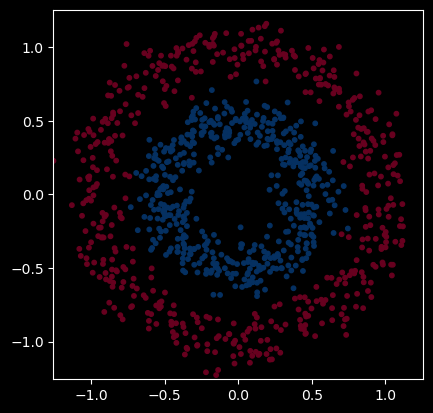

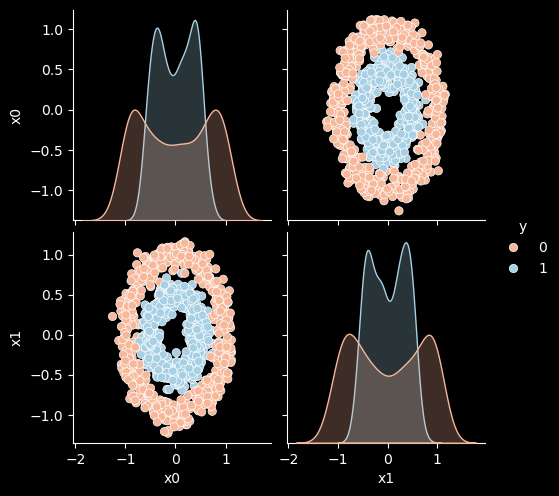

In [3]:
from sklearn.datasets import make_classification, make_blobs, make_moons, make_circles

n_samples = 1000

choice = 3

if   choice == 0:
    X, y = make_blobs(
        n_samples=n_samples,
        n_features=2,
        centers=2,
        cluster_std=5,
        random_state=10
    )
elif choice == 1:
    X, y = make_classification(
        n_samples=n_samples,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_clusters_per_class=1,
        n_classes=3,
        random_state=41
    )
elif choice == 2:
    X, y = make_moons(
        n_samples=n_samples,
        noise=0.2,
        random_state=42
    )
elif choice == 3:
    X, y = make_circles(
        n_samples=n_samples,
        noise=0.1,
        factor=0.5,
        random_state=42
    )

X = X - X.mean(axis=0)

MAX = np.max(np.abs(X))

n_classes = np.unique(y).shape[0]

plt.scatter(X[:,0], X[:,1], c=y, s=10, cmap='RdBu')
plt.xlim(-MAX, MAX)
plt.ylim(-MAX, MAX)
plt.gca().set_aspect('equal')
plt.show()

df = pd.DataFrame({'x0': X[:,0], 'x1': X[:,1], 'y': y})
sns.pairplot(df, hue='y', palette='RdBu')
plt.show()

## Modeling

## Train/test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

## Keras

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162 (648.00 B)

 Trainable params: 162 (648.00 B)

 Non-trainable params: 0 (0.00 B)

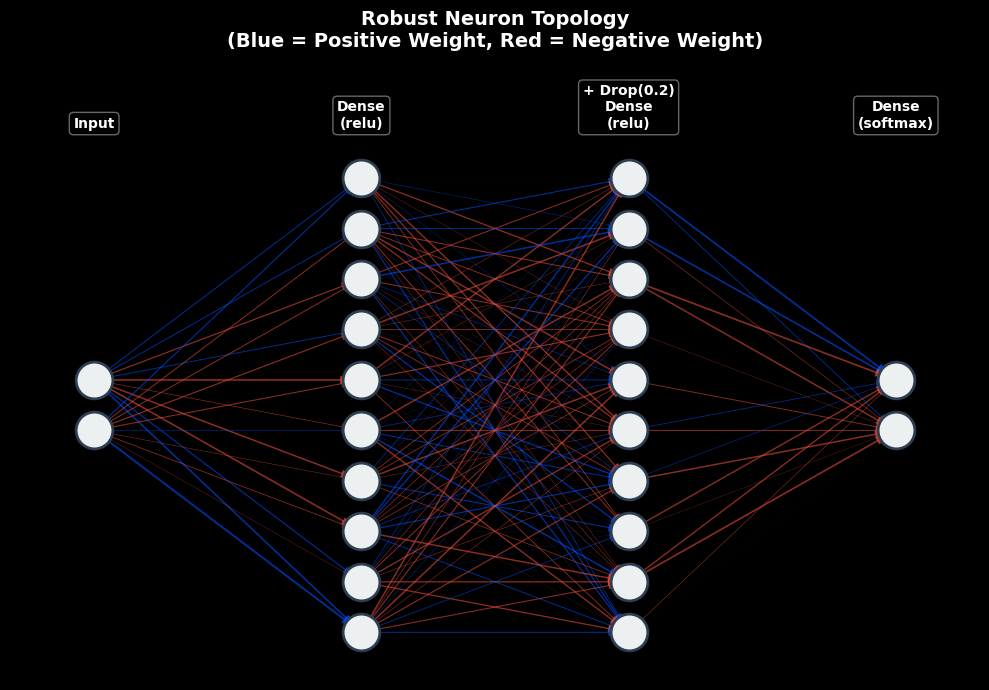

In [5]:
from keras.models import Sequential
from keras.layers import *
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=X.shape[1:]),
    Dense(10, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='relu'),
    Dense(n_classes, activation='softmax'),
])

optimizer = Adam(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True
)

model.summary()

plot_robust_neuron_network(model)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    shuffle=True,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5599 - loss: 0.6721 - val_accuracy: 0.7100 - val_loss: 0.6137
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6863 - loss: 0.6254 - val_accuracy: 0.9350 - val_loss: 0.5261
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8149 - loss: 0.5366 - val_accuracy: 0.9750 - val_loss: 0.3796
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8768 - loss: 0.4037 - val_accuracy: 0.9750 - val_loss: 0.2405
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9059 - loss: 0.2861 - val_accuracy: 0.9800 - val_loss: 0.1619
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9226 - loss: 0.2336 - val_accuracy: 0.9800 - val_loss: 0.1244
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9428 - loss: 0.2162 - val_accuracy: 0.9800 - val_loss: 0.1027
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9465 - loss: 0.1858 - val_accuracy: 0.9900 - 

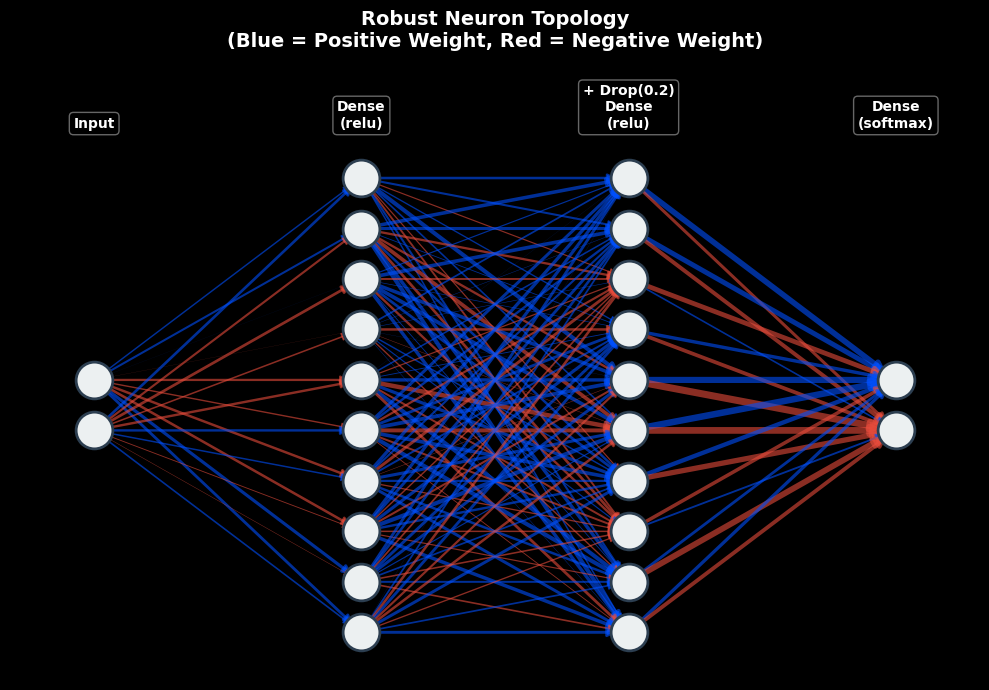

In [7]:
plot_robust_neuron_network(model)

In [8]:
# predict() returns class probabilities (softmax output)
model.predict(X_train)[:5, :]

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step


array([[9.9999976e-01, 2.5947182e-07],
       [9.9995577e-01, 4.4254943e-05],
       [9.9999905e-01, 9.9022702e-07],
       [1.1061260e-02, 9.8893881e-01],
       [1.2332383e-02, 9.8766762e-01]], dtype=float32)

In [9]:
# argmax across class axis gives the predicted class label
y_test_prob = model.predict(X_test)
y_test_pred = y_test_prob.argmax(axis=1)
y_test_pred[:5]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


array([1, 0, 1, 1, 1], dtype=int64)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


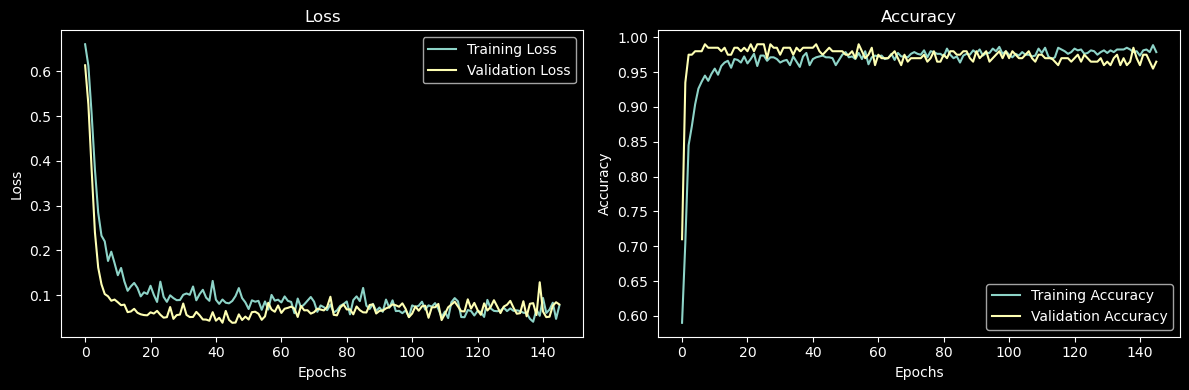

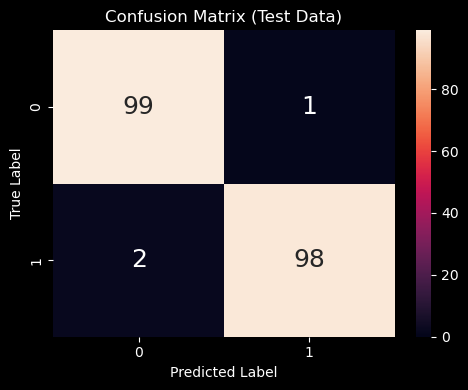

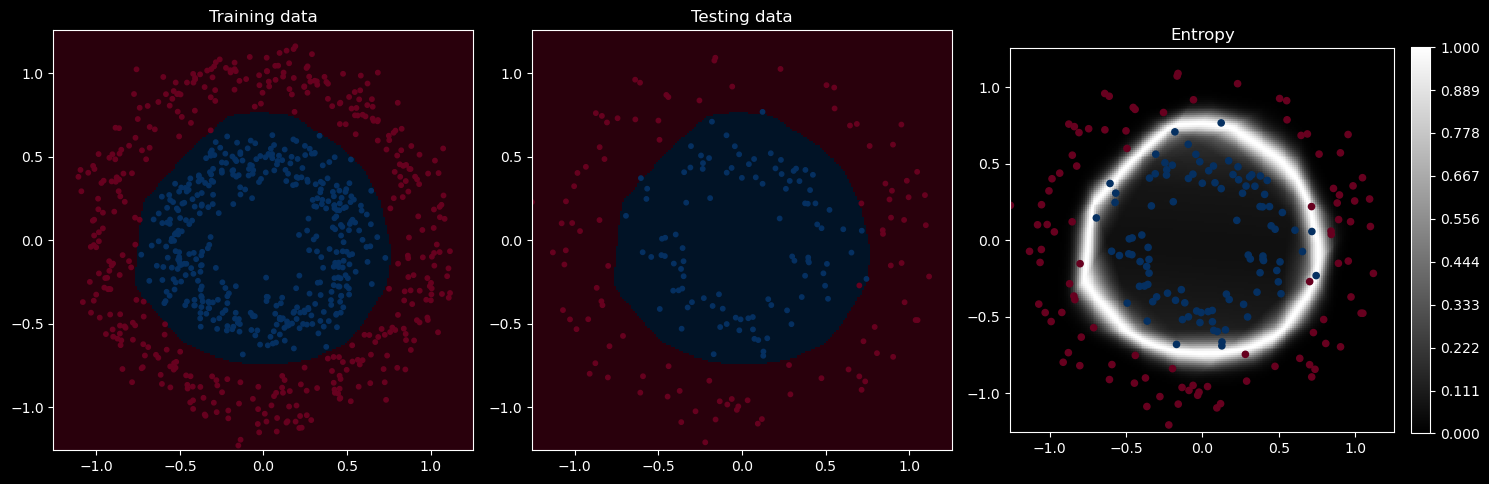

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       100
           1       0.99      0.98      0.98       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



In [10]:
from sklearn.metrics import classification_report, confusion_matrix

y_train_pred = model.predict(X_train).argmax(axis=1)
y_test_pred  = model.predict(X_test).argmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', ax=ax, vmin=0, annot_kws={'size': 18})
ax.set_title('Confusion Matrix (Test Data)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

B, S = visualize_regions_keras(model, MAX, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
extent = [-MAX, MAX, -MAX, MAX]
cmap = 'RdBu'

axes[0].imshow(B, interpolation='none', extent=extent, cmap=cmap, alpha=0.4)
axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap)
axes[0].set_aspect('equal')
axes[0].set_title('Training data')

axes[1].imshow(B, interpolation='none', extent=extent, cmap=cmap, alpha=0.4)
axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap)
axes[1].set_aspect('equal')
axes[1].set_title('Testing data')

im = axes[2].imshow(S, interpolation='none', extent=extent, cmap='gray')
axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap)
axes[2].set_aspect('equal')
axes[2].set_title('Entropy')
cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_ticks(np.linspace(0, math.log(n_classes, 2), 10))

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_test_pred))